# Traffic Accident Data Analysis

## Introduction

This project focuses on analyzing traffic accident data to understand
the patterns and conditions associated with recorded accidents.

The dataset contains information about weather conditions, lighting
conditions, road types, road surface conditions, traffic control devices,
and the time, day, and month of accidents.

In this project, I use Python, Pandas, NumPy, and Matplotlib to clean,
analyze, and visualize the data. The main goal is to identify common
patterns in the accident records and present the findings through
different types of charts.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_csv(r"D:\movies\project\traffic_accidents_india.csv")
print(data)

         vehicle_name    traffic_control_device weather_condition  \
0        Skoda Slavia            TRAFFIC SIGNAL              RAIN   
1          Honda City                     OTHER   CLOUDY/OVERCAST   
2       Toyota Innova         STOP SIGN/FLASHER              RAIN   
3       Renault Kiger               NO CONTROLS              RAIN   
4       Toyota Innova               NO CONTROLS             CLEAR   
...               ...                       ...               ...   
9995    Toyota Innova         STOP SIGN/FLASHER   CLOUDY/OVERCAST   
9996    Renault Kiger          LANE USE MARKING             CLEAR   
9997      Hyundai i20  PEDESTRIAN CROSSING SIGN    FOG/SMOKE/HAZE   
9998      Hyundai i20               NO CONTROLS              RAIN   
9999  Toyota Fortuner               NO CONTROLS             CLEAR   

          lighting_condition             trafficway_type roadway_surface_cond  \
0                       DAWN                 NOT DIVIDED                  WET   
1        

In [4]:
print(data.shape) # means there are 10k rows and 10 columns 

(10000, 10)


In [5]:
print(data.head(10))

    vehicle_name traffic_control_device weather_condition  \
0   Skoda Slavia         TRAFFIC SIGNAL              RAIN   
1     Honda City                  OTHER   CLOUDY/OVERCAST   
2  Toyota Innova      STOP SIGN/FLASHER              RAIN   
3  Renault Kiger            NO CONTROLS              RAIN   
4  Toyota Innova            NO CONTROLS             CLEAR   
5  Hyundai Creta         TRAFFIC SIGNAL             CLEAR   
6  Hyundai Venue      STOP SIGN/FLASHER             CLEAR   
7  Hyundai Verna      STOP SIGN/FLASHER             CLEAR   
8   Skoda Slavia            NO CONTROLS   CLOUDY/OVERCAST   
9   Tata Harrier                  YIELD              RAIN   

       lighting_condition             trafficway_type roadway_surface_cond  \
0                    DAWN                 NOT DIVIDED                  WET   
1                DAYLIGHT  DIVIDED - W/MEDIAN BARRIER                  DRY   
2  DARKNESS, LIGHTED ROAD                 NOT DIVIDED                  WET   
3               

In [6]:
data.describe()

,crash_hour,crash_day_of_week,crash_month
count,10000.000000,10000.00000,10000.000000
mean,12.965200,4.19290,6.790800
std,5.919349,2.03556,3.308373
min,0.000000,1.00000,1.000000
25%,8.000000,2.00000,4.000000
50%,14.000000,4.00000,7.000000
75%,18.000000,6.00000,9.000000
max,23.000000,7.00000,12.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   vehicle_name            10000 non-null  object
 1   traffic_control_device  10000 non-null  object
 2   weather_condition       10000 non-null  object
 3   lighting_condition      10000 non-null  object
 4   trafficway_type         10000 non-null  object
 5   roadway_surface_cond    10000 non-null  object
 6   road_defect             10000 non-null  object
 7   crash_hour              10000 non-null  int64 
 8   crash_day_of_week       10000 non-null  int64 
 9   crash_month             10000 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 781.4+ KB


In [8]:
check_null = data.isnull().sum()
print(check_null)

vehicle_name              0
traffic_control_device    0
weather_condition         0
lighting_condition        0
trafficway_type           0
roadway_surface_cond      0
road_defect               0
crash_hour                0
crash_day_of_week         0
crash_month               0
dtype: int64


In [9]:
print(data) #access data

         vehicle_name    traffic_control_device weather_condition  \
0        Skoda Slavia            TRAFFIC SIGNAL              RAIN   
1          Honda City                     OTHER   CLOUDY/OVERCAST   
2       Toyota Innova         STOP SIGN/FLASHER              RAIN   
3       Renault Kiger               NO CONTROLS              RAIN   
4       Toyota Innova               NO CONTROLS             CLEAR   
...               ...                       ...               ...   
9995    Toyota Innova         STOP SIGN/FLASHER   CLOUDY/OVERCAST   
9996    Renault Kiger          LANE USE MARKING             CLEAR   
9997      Hyundai i20  PEDESTRIAN CROSSING SIGN    FOG/SMOKE/HAZE   
9998      Hyundai i20               NO CONTROLS              RAIN   
9999  Toyota Fortuner               NO CONTROLS             CLEAR   

          lighting_condition             trafficway_type roadway_surface_cond  \
0                       DAWN                 NOT DIVIDED                  WET   
1        

In [10]:
## Check the column names
print(data.columns)

Index(['vehicle_name', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'trafficway_type', 'roadway_surface_cond',
       'road_defect', 'crash_hour', 'crash_day_of_week', 'crash_month'],
      dtype='object')


In [11]:
print(data.dtypes)

vehicle_name              object
traffic_control_device    object
weather_condition         object
lighting_condition        object
trafficway_type           object
roadway_surface_cond      object
road_defect               object
crash_hour                 int64
crash_day_of_week          int64
crash_month                int64
dtype: object


In [12]:
# in this csv file every column 
data["weather_condition"] = data["weather_condition"].astype("category")
data["lighting_condition"] = data["lighting_condition"].astype("category")
data["roadway_surface_cond"] = data["roadway_surface_cond"].astype("category")

In [13]:
print(data.dtypes)

vehicle_name                object
traffic_control_device      object
weather_condition         category
lighting_condition        category
trafficway_type             object
roadway_surface_cond      category
road_defect                 object
crash_hour                   int64
crash_day_of_week            int64
crash_month                  int64
dtype: object


In [14]:
#once checked and converted a datatype now lets check a duplicate values
duplicate_Value = data.duplicated().sum()
print("duplicate values:", duplicate_Value)

duplicate values: 4


In [15]:
#there are multiple catogories columns in this. to count multiple catrogorical numbers
weather_count = data["weather_condition"].value_counts()
print(weather_count)

weather_condition
CLEAR                    2974
RAIN                     2961
CLOUDY/OVERCAST          1609
FOG/SMOKE/HAZE           1277
UNKNOWN                   494
OTHER                     449
SLEET/HAIL                143
FREEZING RAIN/DRIZZLE      59
BLOWING SNOW               17
SNOW                       17
Name: count, dtype: int64


In [16]:
lighting_condition = data["lighting_condition"].value_counts()
print(lighting_condition)

lighting_condition
DAYLIGHT                  5194
DARKNESS                  2163
DARKNESS, LIGHTED ROAD    1244
DUSK                       635
DAWN                       504
UNKNOWN                    260
Name: count, dtype: int64


In [17]:
roadway_surface_cond = data["roadway_surface_cond"].value_counts()
print(roadway_surface_cond)

roadway_surface_cond
DRY                4526
WET                3185
SAND, MUD, DIRT    1272
OTHER               609
UNKNOWN             383
SNOW OR SLUSH        22
ICE                   3
Name: count, dtype: int64


In [18]:
#there are week days also in the columns which are given in integer, to convert in weekdays this method i used
# in this syntex map function is used
# Data Preparation
day_names = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

data["crash_day_name"] = data["crash_day_of_week"].map(day_names)

#same we do with month in crash month folder, to convert it into the monnth name...
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

data["crash_month_name"] = data["crash_month"].map(month_names)

In [19]:
print(data)

         vehicle_name    traffic_control_device weather_condition  \
0        Skoda Slavia            TRAFFIC SIGNAL              RAIN   
1          Honda City                     OTHER   CLOUDY/OVERCAST   
2       Toyota Innova         STOP SIGN/FLASHER              RAIN   
3       Renault Kiger               NO CONTROLS              RAIN   
4       Toyota Innova               NO CONTROLS             CLEAR   
...               ...                       ...               ...   
9995    Toyota Innova         STOP SIGN/FLASHER   CLOUDY/OVERCAST   
9996    Renault Kiger          LANE USE MARKING             CLEAR   
9997      Hyundai i20  PEDESTRIAN CROSSING SIGN    FOG/SMOKE/HAZE   
9998      Hyundai i20               NO CONTROLS              RAIN   
9999  Toyota Fortuner               NO CONTROLS             CLEAR   

          lighting_condition             trafficway_type roadway_surface_cond  \
0                       DAWN                 NOT DIVIDED                  WET   
1        

In [20]:
#as we created new 2 catogories name month and weekdays, 
#they are also catogory so we have to convert it into the category instead of store them as an object
print(data.dtypes)

vehicle_name                object
traffic_control_device      object
weather_condition         category
lighting_condition        category
trafficway_type             object
roadway_surface_cond      category
road_defect                 object
crash_hour                   int64
crash_day_of_week            int64
crash_month                  int64
crash_day_name              object
crash_month_name            object
dtype: object


In [21]:
data["crash_day_name"] = data["crash_day_name"].astype("category")
data["crash_month_name"] = data["crash_month_name"].astype("category")
print(data.dtypes)

vehicle_name                object
traffic_control_device      object
weather_condition         category
lighting_condition        category
trafficway_type             object
roadway_surface_cond      category
road_defect                 object
crash_hour                   int64
crash_day_of_week            int64
crash_month                  int64
crash_day_name            category
crash_month_name          category
dtype: object


In [22]:
road_defects = data["road_defect"].value_counts()
print(road_defects)

road_defect
NO DEFECTS           4138
RUT, HOLES           2532
WORN SURFACE         1628
DEBRIS ON ROADWAY     712
SHOULDER DEFECT       498
OTHER                 284
UNKNOWN               208
Name: count, dtype: int64


In [23]:
# in the column road defect most common values are unknown or no defect s we will drop that column
data = data.drop("road_defect", axis = 1)

In [24]:
print(data)

         vehicle_name    traffic_control_device weather_condition  \
0        Skoda Slavia            TRAFFIC SIGNAL              RAIN   
1          Honda City                     OTHER   CLOUDY/OVERCAST   
2       Toyota Innova         STOP SIGN/FLASHER              RAIN   
3       Renault Kiger               NO CONTROLS              RAIN   
4       Toyota Innova               NO CONTROLS             CLEAR   
...               ...                       ...               ...   
9995    Toyota Innova         STOP SIGN/FLASHER   CLOUDY/OVERCAST   
9996    Renault Kiger          LANE USE MARKING             CLEAR   
9997      Hyundai i20  PEDESTRIAN CROSSING SIGN    FOG/SMOKE/HAZE   
9998      Hyundai i20               NO CONTROLS              RAIN   
9999  Toyota Fortuner               NO CONTROLS             CLEAR   

          lighting_condition             trafficway_type roadway_surface_cond  \
0                       DAWN                 NOT DIVIDED                  WET   
1        

In [25]:
print(data.columns)

Index(['vehicle_name', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'trafficway_type', 'roadway_surface_cond',
       'crash_hour', 'crash_day_of_week', 'crash_month', 'crash_day_name',
       'crash_month_name'],
      dtype='object')


In [26]:
#now we have a clean data on which we can do a analysis
# 1. Total number of accidents
print("1. Total accidents:", len(data))

# 2. Most common weather condition
print("2. Most common weather:",
      data["weather_condition"].value_counts().idxmax())

# 3. Most common lighting condition
print("3. Most common lighting:",
      data["lighting_condition"].value_counts().idxmax())

# 4. Most common road type
print("4. Most common road type:",
      data["trafficway_type"].value_counts().idxmax())

# 5. Most common road surface condition
print("5. Most common road surface:",
      data["roadway_surface_cond"].value_counts().idxmax())

# 6 Most common traffic control device
print("7. Most common traffic control:",
      data["traffic_control_device"].value_counts().idxmax())

# 7. Most dangerous hour
print("8. Most dangerous hour:",
      data["crash_hour"].value_counts().idxmax())

# 8. Most dangerous day
print("9. Most dangerous day:",
      data["crash_day_name"].value_counts().idxmax())

# 9. Most dangerous month
print("10. Most dangerous month:",
      data["crash_month_name"].value_counts().idxmax())

1. Total accidents: 10000
2. Most common weather: CLEAR
3. Most common lighting: DAYLIGHT
4. Most common road type: NOT DIVIDED
5. Most common road surface: DRY
7. Most common traffic control: NO CONTROLS
8. Most dangerous hour: 17
9. Most dangerous day: Friday
10. Most dangerous month: July


# now lets move to the charts and to visualize data


# 1. Traffic Accidents by Hour


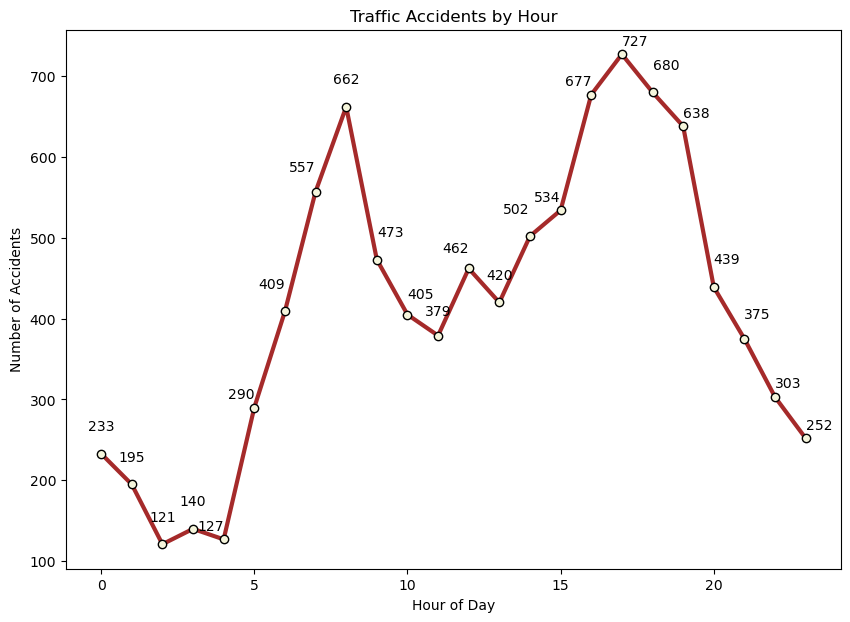

In [33]:
hour_count = data["crash_hour"].value_counts().sort_index()

plt.figure(figsize=(10, 7))
plt.plot(
    hour_count.index,
    hour_count.values,
    color="brown",
    linewidth = 3,
    marker="o",
    markerfacecolor="beige",
    markeredgecolor="black"
)
ha_position = ["center", "center", "center", "center", "right",
               "right", "right", "right", "center", "left",
               "left", "center", "right", "center", "right",
               "right", "right", "left", "left", "left",
               "left", "left", "left", "left" ]
va_position = sitions = [
    "bottom", "bottom", "bottom", "bottom", "top",
    "top", "bottom", "baseline", "bottom", "bottom",
    "center", "baseline", "center", "bottom", "bottom",
    "top", "top", "top", "bottom", "top",
    "bottom", "baseline", "top", "top"
]
plt.title("Traffic Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
for i, val in enumerate(hour_count.values):
    plt.text( i, val + 25 , str(val), ha= ha_position[i], va=va_position[i])
plt.show()


# Shows how accident frequency changes throughout the day and identifies the hours with the highest number of accidents

# Traffic Accidents by Lighting Condition


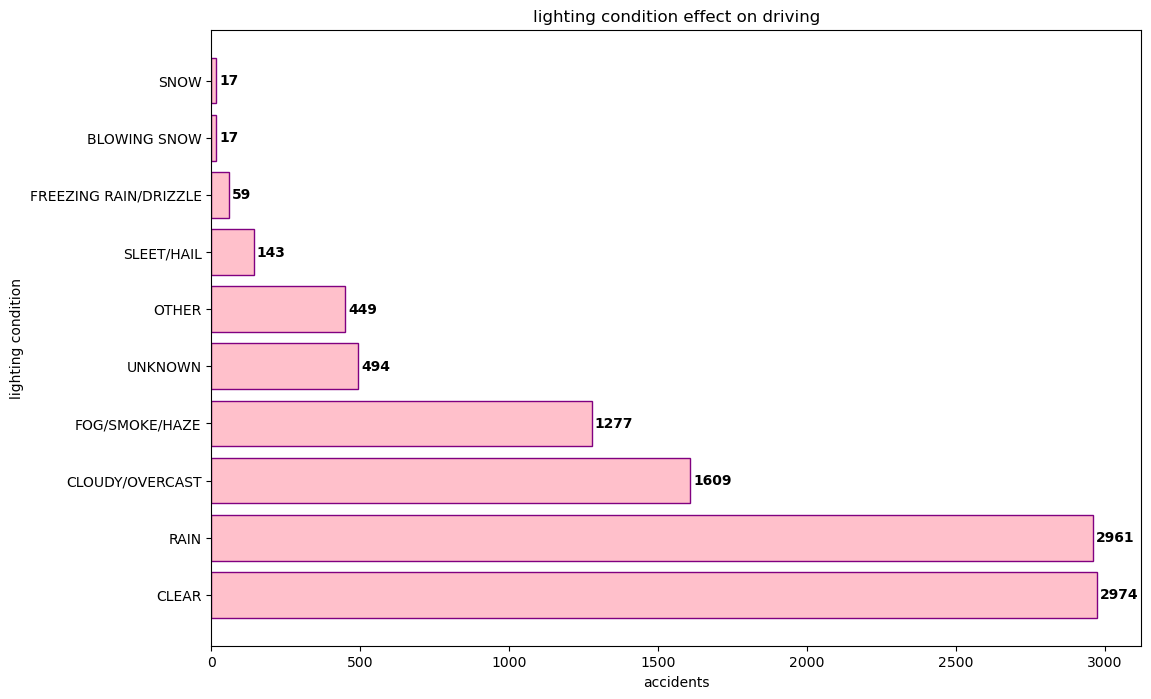

In [28]:
plt.figure(figsize=(12, 8))

plt.barh(weather_count.index, weather_count.values, color = "pink", edgecolor = "purple")
plt.xlabel("accidents")
plt.ylabel("lighting condition")
plt.title("lighting condition effect on driving")
for i, v in enumerate(weather_count.values):
    plt.text(v + 10, i, str(v), va="center", fontweight="bold")
plt.show()

# Traffic Accidents by Lighting Condition (Pie chart)

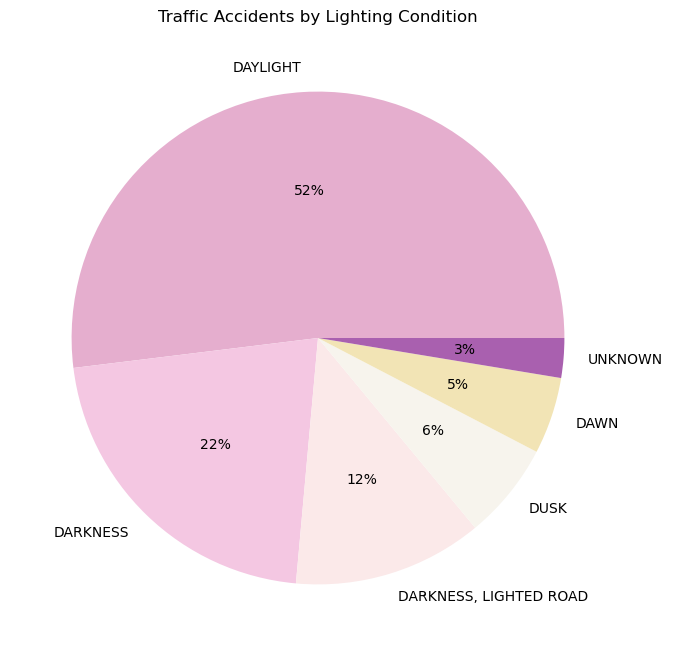

In [29]:
lighting_count = data["lighting_condition"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    lighting_count.values,
    labels=lighting_count.index,
    autopct="%0.00f%%",
    colors = ["#E5AECE", "#F4C7E2", "#FBE9E9", "#F7F4ED", "#F2E4B5", "#A960AF"]
)

plt.title("Traffic Accidents by Lighting Condition")

plt.show()


# Traffic Accidents by Month

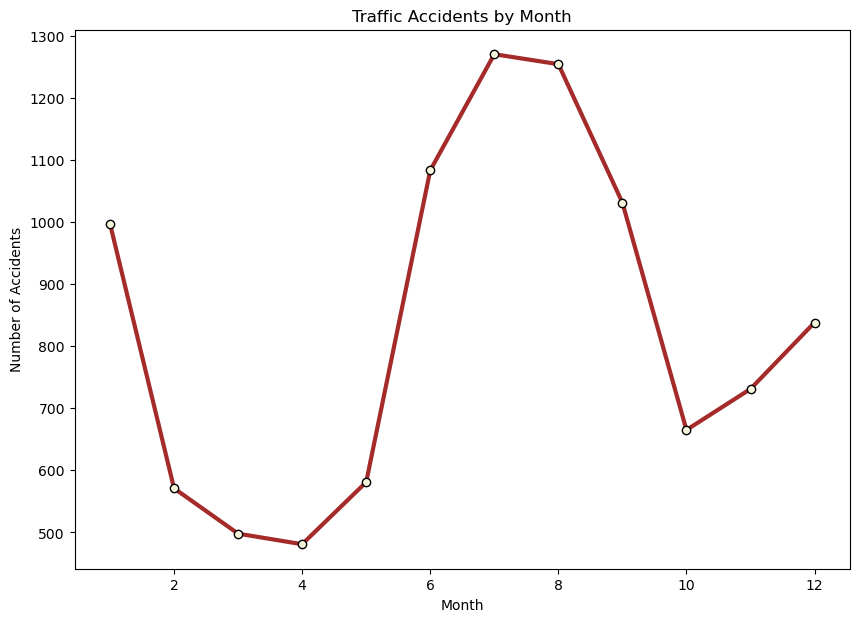

In [37]:
month_count = data["crash_month"].value_counts().sort_index()

plt.figure(figsize=(10, 7))

plt.plot(month_count.index, month_count.values, color="brown", linewidth=3, marker="o", markerfacecolor="beige", markeredgecolor="black")

plt.title("Traffic Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.show()
# Shows how accident frequency varies across different months of the year.

# Accident Frequency vs. Hour of Day

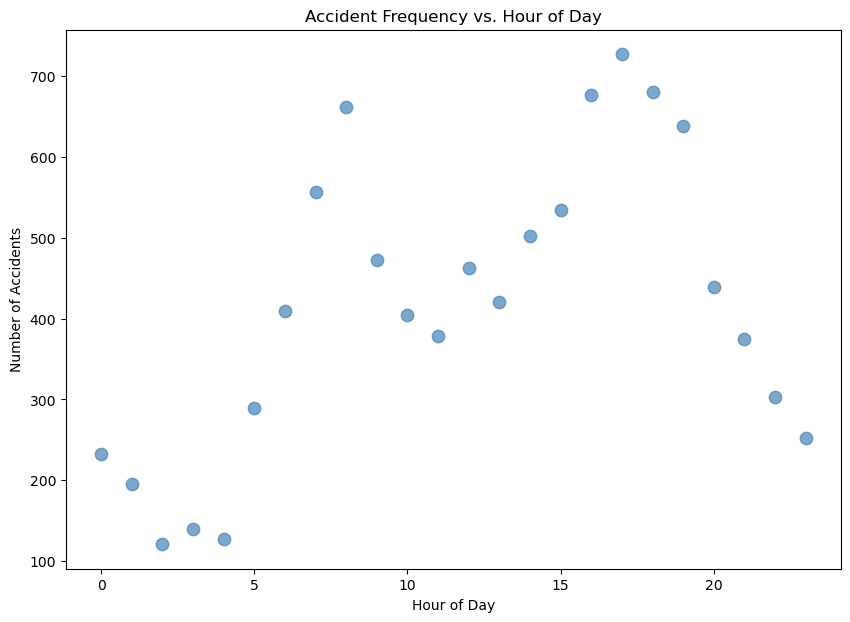

In [31]:
hour_count = data["crash_hour"].value_counts().sort_index()

plt.figure(figsize=(10, 7))

plt.scatter(hour_count.index, hour_count.values, s=80, alpha=0.7, color = "steelblue")

plt.title("Accident Frequency vs. Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")

plt.show()
# Shows the relationship between the hour of the day and the number of recorded accidents.

# Number of Accidents by Road Type

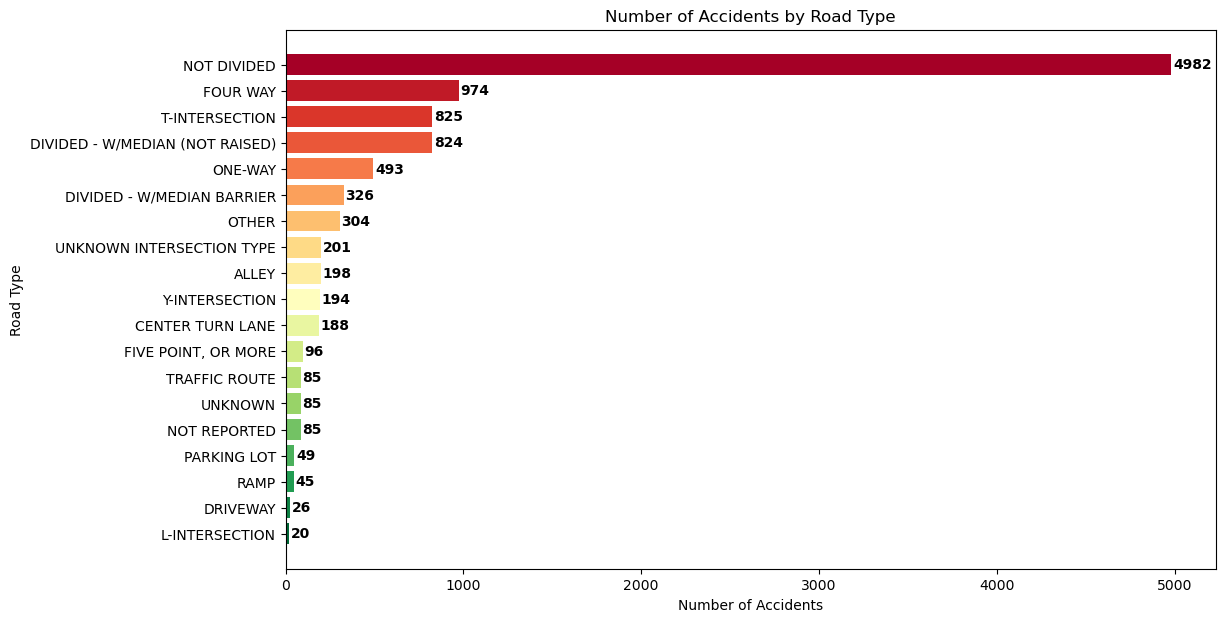

In [32]:
road_accidents = data.groupby("trafficway_type").size().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(road_accidents)))

plt.figure(figsize=(12, 7))

plt.barh(
    road_accidents.index, road_accidents.values, color=colors)

plt.title("Number of Accidents by Road Type")
plt.xlabel("Number of Accidents")
plt.ylabel("Road Type")

for i, v in enumerate(road_accidents.values):
    plt.text(v + 10, i, str(v), va="center", fontweight="bold")

plt.show()
#Compares accident counts across different road types to identify where accidents are recorded most frequently.

## Key Findings

From the analysis and visualizations, some important patterns were
observed in the recorded accident data.

- Clear weather had the highest number of recorded accidents.
- Daylight had the highest number of recorded accidents.
- Friday had the highest number of recorded accidents.
- July had the highest number of recorded accidents.
- 17:00 was the hour with the highest recorded accident count.
- Accident counts varied across different road types.

These findings describe patterns in the available accident records.
They do not necessarily mean that these conditions directly cause
accidents.

# Conclusion

This project helped me analyze traffic accident data using Python.

I used Pandas to load, clean, and analyze the dataset, NumPy for
numerical calculations, and Matplotlib for data visualization.

The analysis showed different patterns in accident records based on
time, weather, lighting, month, and road type.

The charts made it easier to compare these patterns and understand
where the recorded accident counts were higher or lower.

Overall, this project helped me understand how Python can be used to
analyze real-world data and present the results in a clear and simple
way.